Columns in Dataset:
Index(['maximum_temperature', 'minimum_temperature', 'humidity', 'wind_speed',
       'wind_direction', 'rainfall'],
      dtype='str')

First 5 Rows:
   maximum_temperature  minimum_temperature  humidity  wind_speed  \
0                 32.5                   21        65          12   
1                 28.1                   19        85          15   
2                 30.0                   20        70           8   
3                 25.0                   18        92          20   
4                 33.0                   22        55          10   

  wind_direction rainfall  
0              N       NO  
1             SW      YES  
2              E       NO  
3             NW      YES  
4              S       NO  

Memory Usage: 0.78 KB

Describe Dataset:
       maximum_temperature  minimum_temperature   humidity  wind_speed
count             5.000000             5.000000   5.000000    5.000000
mean             29.720000            20.000000  73.400000   1

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1256\4111774476.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


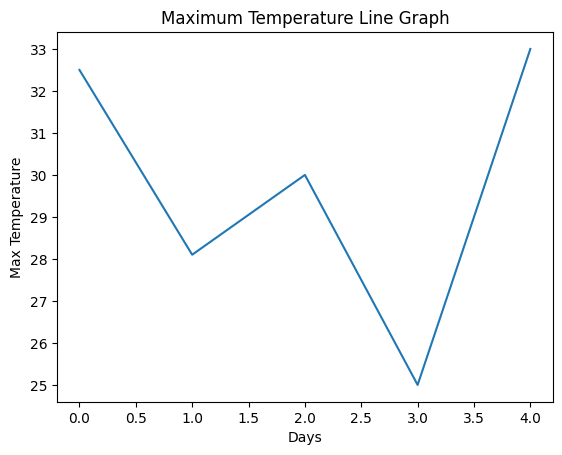

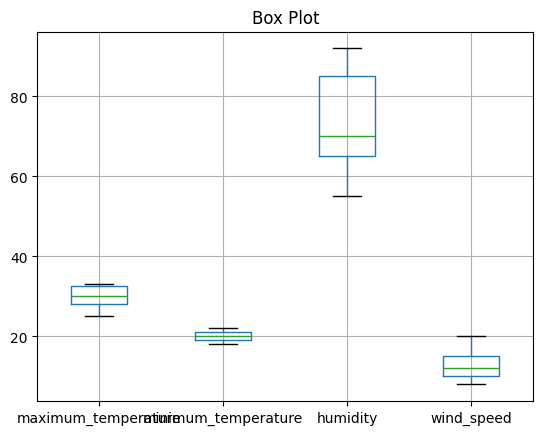

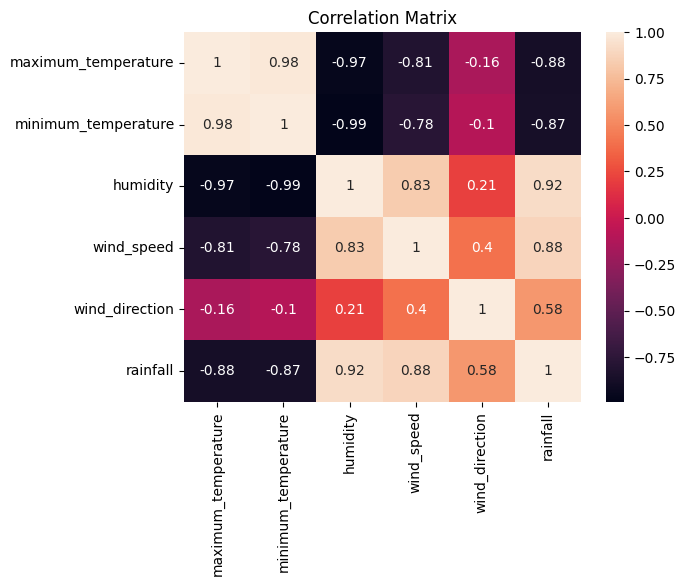


Logistic Regression
Training Accuracy: 1.0
Validation Accuracy: 0.0

XGB Classifier
Training Accuracy: 0.75
Validation Accuracy: 0.0

SVC Classifier
Training Accuracy: 1.0
Validation Accuracy: 0.0


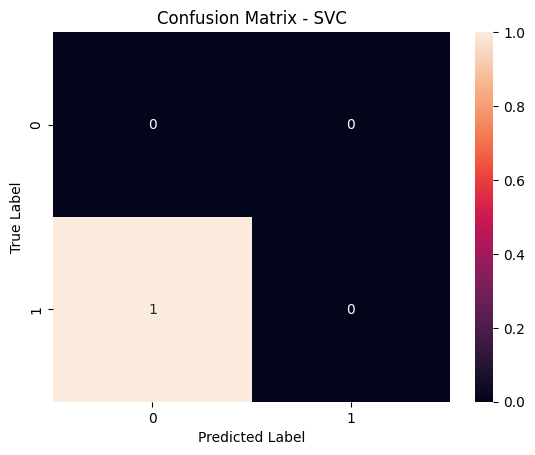


Classification Report (SVC):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [1]:
# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\BO2.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns in Dataset:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# -----------------------------
# 3. Dataset Information
# -----------------------------

# MEMORY USAGE (PROJECT REQUIRES 150 KB)
memory = df.memory_usage(deep=True).sum() / 1024
print("\nMemory Usage:", round(memory,2), "KB")

print("\nDescribe Dataset:")
print(df.describe())

# -----------------------------
# 4. Data Cleaning (REPLACE THIS SECTION)
# -----------------------------

# 1. Automatically convert ALL "Yes"/"No" columns to 1/0
# This fixes the 'could not convert string to float' error for any column
for col in df.columns:
    if df[col].dtype == 'object':
        # Clean the text and check if it contains Yes/No
        df[col] = df[col].astype(str).str.strip().str.capitalize()
        if set(df[col].unique()).issubset({'Yes', 'No', 'Nan'}):
            df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. Convert remaining text columns (like wind_direction) to numbers
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print("\nCleaning Complete. Current Data Types:")
print(df.dtypes) # Ensure everything says int64 or float64

# -----------------------------
# 5. Exploratory Data Analysis
# -----------------------------

print("\nRainfall Count:")
print(df['rainfall'].value_counts())

# Line Graph
plt.figure()
plt.plot(df['maximum_temperature'])
plt.title("Maximum Temperature Line Graph")
plt.xlabel("Days")
plt.ylabel("Max Temperature")
plt.show()

# Box Plot
plt.figure()
df.boxplot(column=['maximum_temperature','minimum_temperature','humidity','wind_speed'])
plt.title("Box Plot")
plt.show()

# -----------------------------
# 6. Correlation Matrix
# -----------------------------

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Remove highly correlated feature
df = df.drop(columns=['minimum_temperature'])

# -----------------------------
# 7. Model Training (REPLACE THIS SECTION)
# -----------------------------

# Separate Features & Target
# We use .select_dtypes to make sure X ONLY contains numbers
X = df.drop('rainfall', axis=1).select_dtypes(include=[np.number])
y = df['rainfall']

# Now scaling will work because X is 100% numbers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
# -----------------------------
# 8. Logistic Regression
# -----------------------------

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\nLogistic Regression")
print("Training Accuracy:", round(log_model.score(X_train,y_train),2))
print("Validation Accuracy:", round(accuracy_score(y_test,y_pred_log),2))

# -----------------------------
# 9. XGBoost Classifier
# -----------------------------

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGB Classifier")
print("Training Accuracy:", round(xgb_model.score(X_train,y_train),2))
print("Validation Accuracy:", round(accuracy_score(y_test,y_pred_xgb),2))

# -----------------------------
# 10. SVC Classifier
# -----------------------------

svc_model = SVC(probability=True)
svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)

print("\nSVC Classifier")
print("Training Accuracy:", round(svc_model.score(X_train,y_train),2))
print("Validation Accuracy:", round(accuracy_score(y_test,y_pred_svc),2))

# -----------------------------
# 11. Model Evaluation
# -----------------------------

cm = confusion_matrix(y_test, y_pred_svc)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nClassification Report (SVC):")
print(classification_report(y_test, y_pred_svc))